In [ ]:
# -*- coding: utf-8 -*-
#  Copyright 2025 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Laura Murgatroyd (UKRI-STFC)

# Applying SIRT to Golden Angle Data

This notebook demonstrates applying SIRT - an iterative reconstruction algorithm -  to data acquired with the golden angle protocol.

The notebook compares the results of SIRT with and without a non-negativity constraint applied to the golden ratio data with 25%, 50% and 75% of the total number of projections acquired in the equidistant scan protocol.

In [ ]:
import os

import warnings
warnings.filterwarnings("ignore")

from cil.utilities.display import show2D, show1D
from cil.processors import Slicer
from cil.plugins.astra import ProjectionOperator
from cil.optimisation.algorithms import SIRT
from cil.optimisation.functions import IndicatorBox
from cil.optimisation.utilities.callbacks import ProgressCallback
from cil.io import NEXUSDataWriter

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.stopping_rules import SharpnessCallback
from utils.lego_man import get_sharpness_slicers, calculate_metrics, make_bar_plots

## Data

This notebook uses a dataset of a lego man imaged at IMAT. The lego man is inside a lead container.

The same sample was imaged twice:

1. Equidistant protocol: with angles incrementally increased by the same amount and rotated through a total of 360 degrees.

2. Golden ratio protocol: angles increased by an amount determined by the golden ratio, across 180 degrees.

You will need to download the dataset `preprocessed_data.zip` from https://zenodo.org/records/17814677:

    https://zenodo.org/records/17814677/files/preprocessed_data.zip

Please update the filepath below:

In [2]:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=100*10**-4)
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=100*10**-4)

In [12]:
equi_full_slice = equi_full.get_slice(vertical=317)
equi_full_slice.reorder('astra')
equi_full_recon = run_weighted_fbp_parallel(equi_full_slice)

Make reduced versions of the golden angle data with 25%, 50% and 75% of angles:

In [13]:
gr_scales = [0.25, 0.5, 0.75]
gr_slices = {gr_scale: Slicer(roi={'angle': (0, 457 * gr_scale), 'vertical': (317, 318)})(gr_full) for gr_scale in gr_scales}
gr_slices_fbp = {gr_scale: run_weighted_fbp_parallel(gr_slice) for gr_scale, gr_slice in gr_slices.items()}

## Setup and run the SIRT algorithm

For each data slice we setup a SIRT (Simultaneous Iterative Reconstruction Technique) algorithm:

In [14]:
sirt_algos = {gr_scale: None for gr_scale in gr_scales}


# --- build unconstrained SIRT algorithms ---
for gr_scale, gr_slice in gr_slices.items():
    A = ProjectionOperator(gr_slice.geometry.get_ImageGeometry(), gr_slice.geometry)
    ig = gr_slice.geometry.get_ImageGeometry()

    sirt = SIRT(operator=A, data=gr_slice)
    sirt.update_objective_interval = 10
    sirt_algos[gr_scale] = sirt

We run each algorithm for a maximum of 500 iterations.

SIRT exhibits semi-convergence, meaning that it approaches the ground truth up to a point and then further iterations cause the solution to become more noisy, diverging from the ground truth. This means the number of iterations plays the role of a regularisation parameter, and we can't use convergence of the algorithm as a stopping point.

In this notebook we use a rule based on image sharpness to determine the number of iterations.
The SharpnessCallback terminates iterations early if the sharpness condition has been reached:

In [6]:

iteration_nums = 500
sirt_callbacks = {gr_scale: None for gr_scale in gr_scales}

for gr_scale, sirt in sirt_algos.items():
    sirt_callbacks[gr_scale] = SharpnessCallback(get_sharpness_slicers())
    sirt.run(iteration_nums, callbacks=[ProgressCallback(), sirt_callbacks[gr_scale]])

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

This sharpness stopping rule was demonstrated, along with other SIRT stopping rules in:
Warnett, Jason. (2024). "Don't stop me now!": Stopping rules for iterative reconstruction with dimensional X-ray Computed Tomography. 10.13140/RG.2.2.22554.45766. 

More details on our use of the sharpness stopping rule can be found in Golden_Angle_03_SIRT_Stopping_Point.ipynb

For more info on SIRT see: https://tomographicimaging.github.io/CIL/nightly/optimisation/#cil.optimisation.algorithms.SIRT

Here we compare the SIRT results with:
- The FBP of the full equidistant data (the closest thing we have to 'ground truth')
- The weighted FBP (wFBP) of the reduced golden angle data

We are taking a look at a zoomed in region of the reconstructed slice through the lego man's head

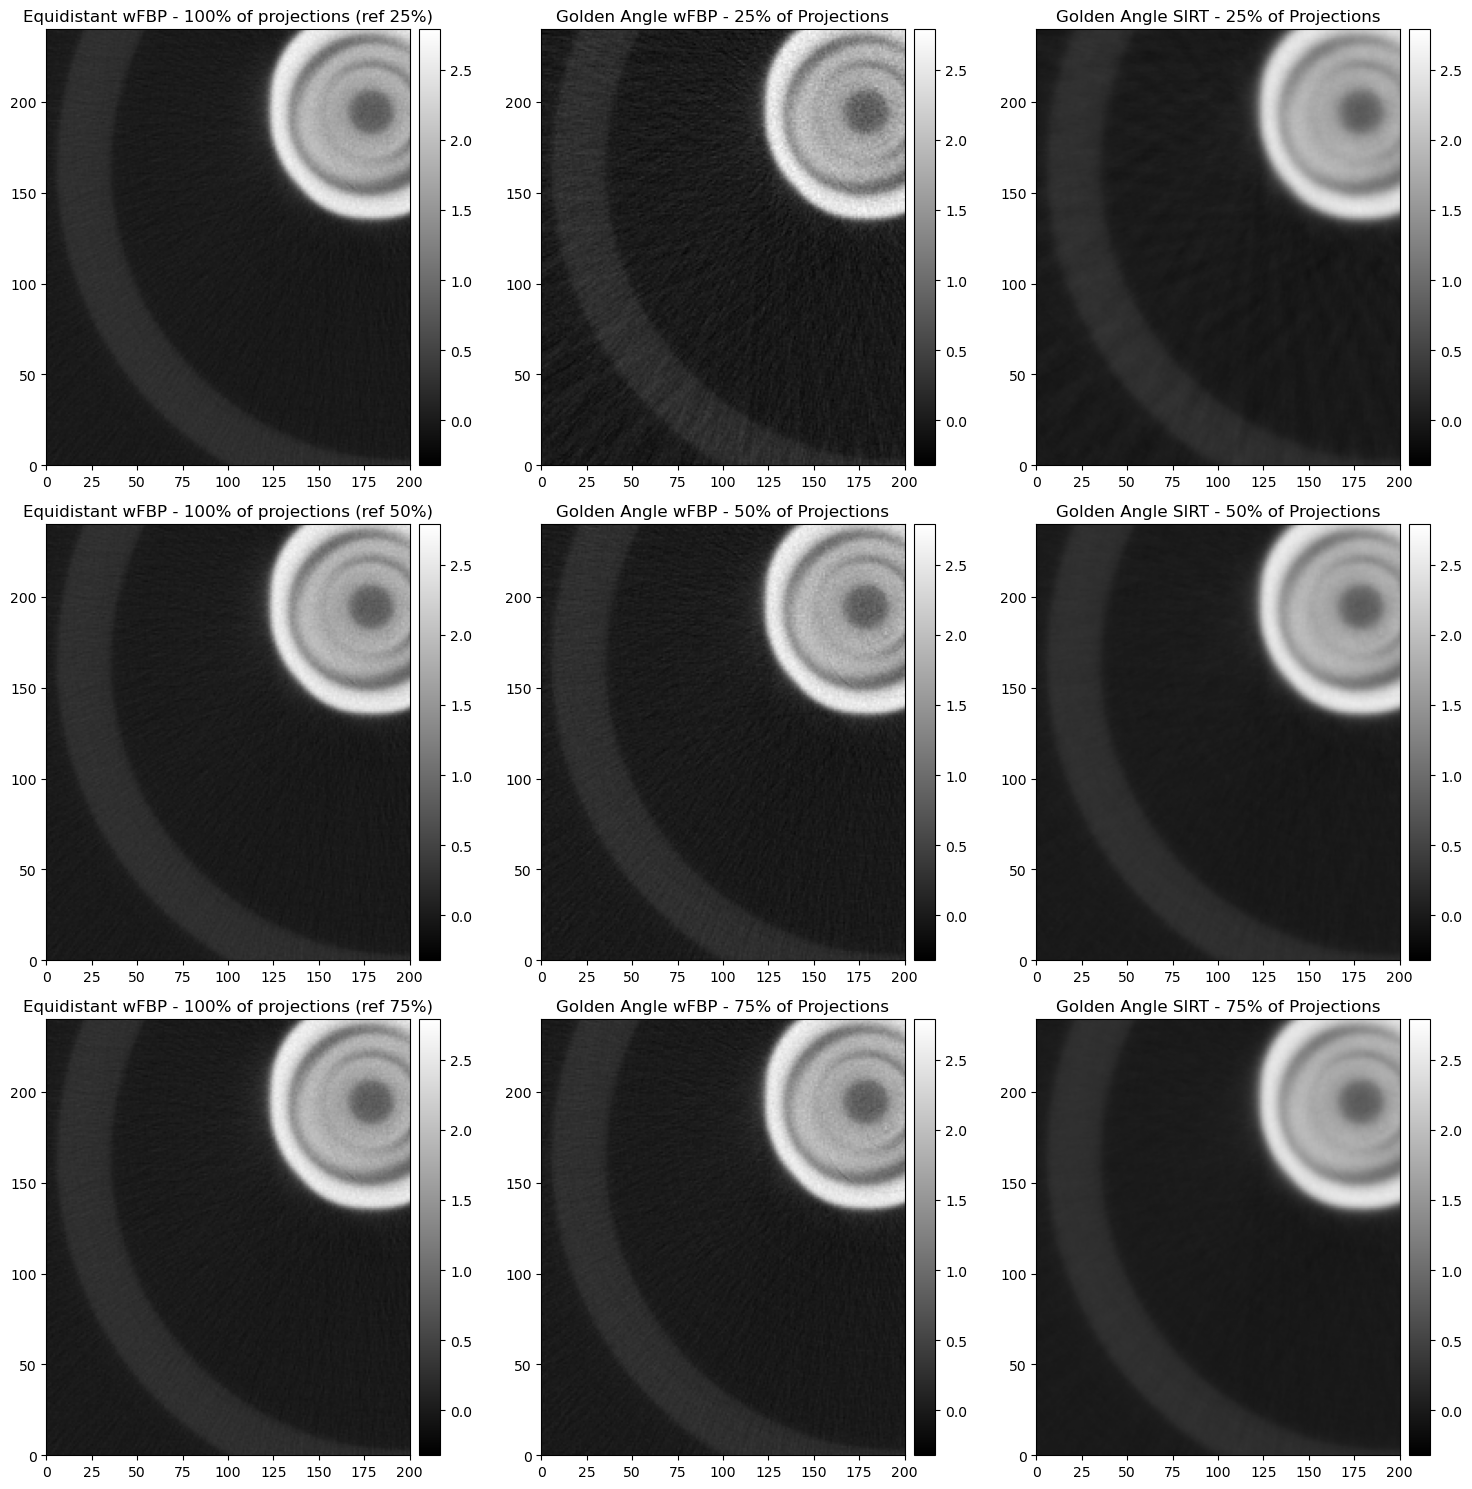

In [7]:
sirt_titles = [f"Golden Angle SIRT - {gr_scale*100:.0f}% of Projections" for gr_scale in gr_scales]
sirt_results = [sirt_algos[gr_scale].solution for gr_scale in gr_scales]
fbp_titles = [f"Golden Angle wFBP - {gr_scale*100:.0f}% of Projections" for gr_scale in gr_scales]
fbp_results = [gr_slices_fbp[gr_scale] for gr_scale in gr_scales]

images = []
titles = []
zoomed_equi_recon = equi_full_recon
for gr_scale, sirt_img, sirt_title, fbp_img, fbp_title in zip(gr_scales, sirt_results, sirt_titles, fbp_results, fbp_titles):
    images.extend([zoomed_equi_recon,fbp_img, sirt_img])
    titles.extend([f"Equidistant FBP - 100% of Proj (ref {gr_scale*100:.0f}%)", fbp_title, sirt_title])

# min is min of all images, max is max of all images
vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)

show2D([x.array[110:350, 100:300] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

## Setup and run the SIRT algorithm with a Non-negativity Constraint (SIRT-NN)

The values in the reconstructed image correspond to the materials' attenuation coefficient, which must be a positive number.

This means we shouldn't have negative values in the reconstructed image.

The non-negativity constraint enforces this.

For each data slice we setup a SIRT algorithm with a non-negativity constraint, and we refer to this as SIRT-NN (SIRT non-negativity):

In [8]:
sirt_nn_algos = {gr_scale: None for gr_scale in gr_scales}

for gr_scale, gr_slice in gr_slices.items():
    A = ProjectionOperator(gr_slice.geometry.get_ImageGeometry(), gr_slice.geometry)
    ig = gr_slice.geometry.get_ImageGeometry()
    constraint = IndicatorBox(lower=0)

    sirt_nn = SIRT(operator=A, data=gr_slice, constraint=constraint)
    sirt_nn.update_objective_interval = 10
    sirt_nn_algos[gr_scale] = sirt_nn


sirt_nn_callbacks = {gr_scale: None for gr_scale in gr_scales}
# --- loop 1: run SIRT with non-negativity constraint ---
for gr_scale, sirt_nn in sirt_nn_algos.items():
    sirt_nn_callbacks[gr_scale] = SharpnessCallback(get_sharpness_slicers(), threshold=0.25)

    sirt_nn.run(iteration_nums, callbacks=[ProgressCallback(), sirt_nn_callbacks[gr_scale]])


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

## Compare results of SIRT and SIRT-NN

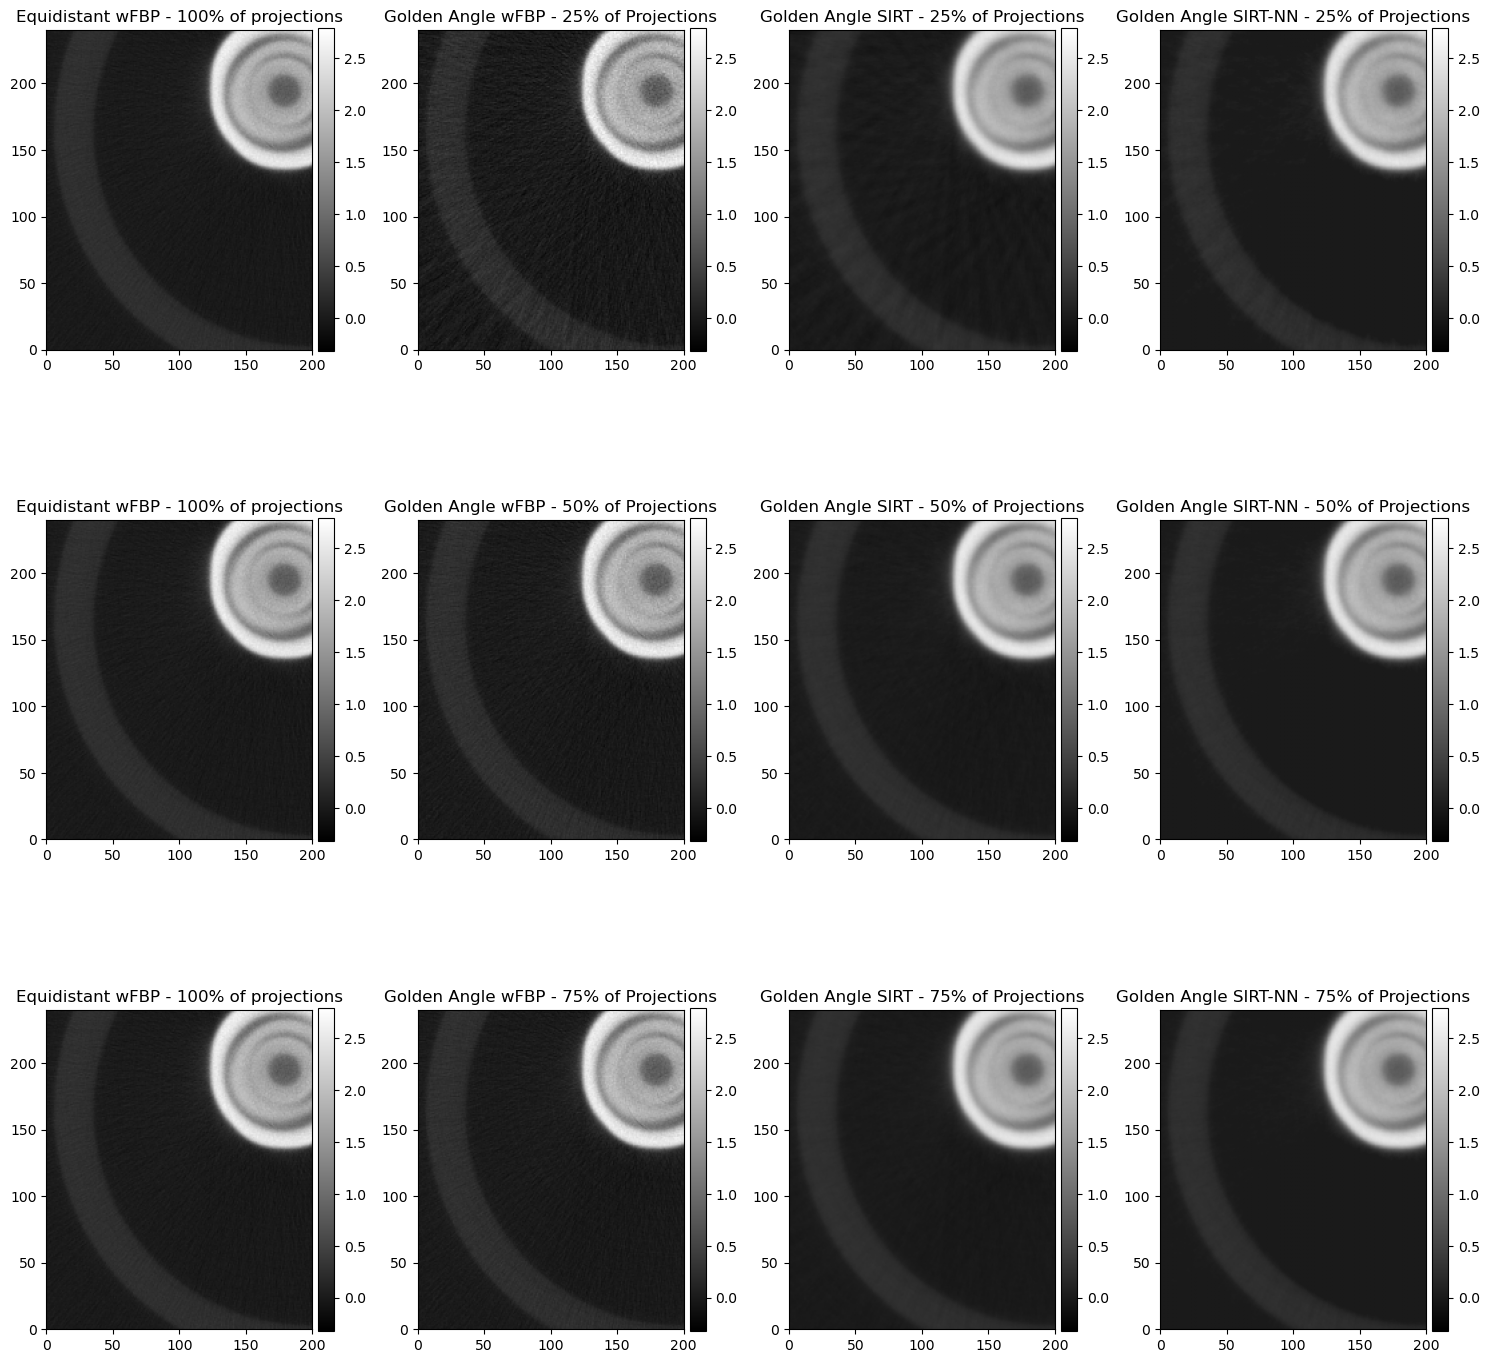

In [9]:
sirt_nn_titles = [f"Golden Angle SIRT-NN - {gr_scale*100:.0f}% of Projections" for gr_scale in gr_scales]
sirt_nn_results = [sirt_nn_algos[gr_scale].solution for gr_scale in gr_scales]

images = []
titles = []
for gr_scale, sirt_img, sirt_title, fbp_img, fbp_title, sirt_nn_img, sirt_nn_title in zip(gr_scales, sirt_results, sirt_titles, fbp_results, fbp_titles, sirt_nn_results, sirt_nn_titles):
    images.extend([zoomed_equi_recon,fbp_img, sirt_img, sirt_nn_img])
    titles.extend([f"Equidistant wFBP - 100% of projections", fbp_title, sirt_title, sirt_nn_title])

# min is min of all images, max is max of all images
vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)

show2D([x.array[110:350, 100:300] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=4)

We can see that with the non-negativity constraint the background has been smoothed more, with this being particularly noticeable when we have 25% of the data.

The ring artifacts visible in the golden angle wFBP reconstructions are not visible in the SIRT and SIRT-NN reconstructions.

In and outside of the lego and lead we see reduced noise in the images but it looks like some of the boundaries might be blurred. Lets take a look at the line profiles and metrics to find out.

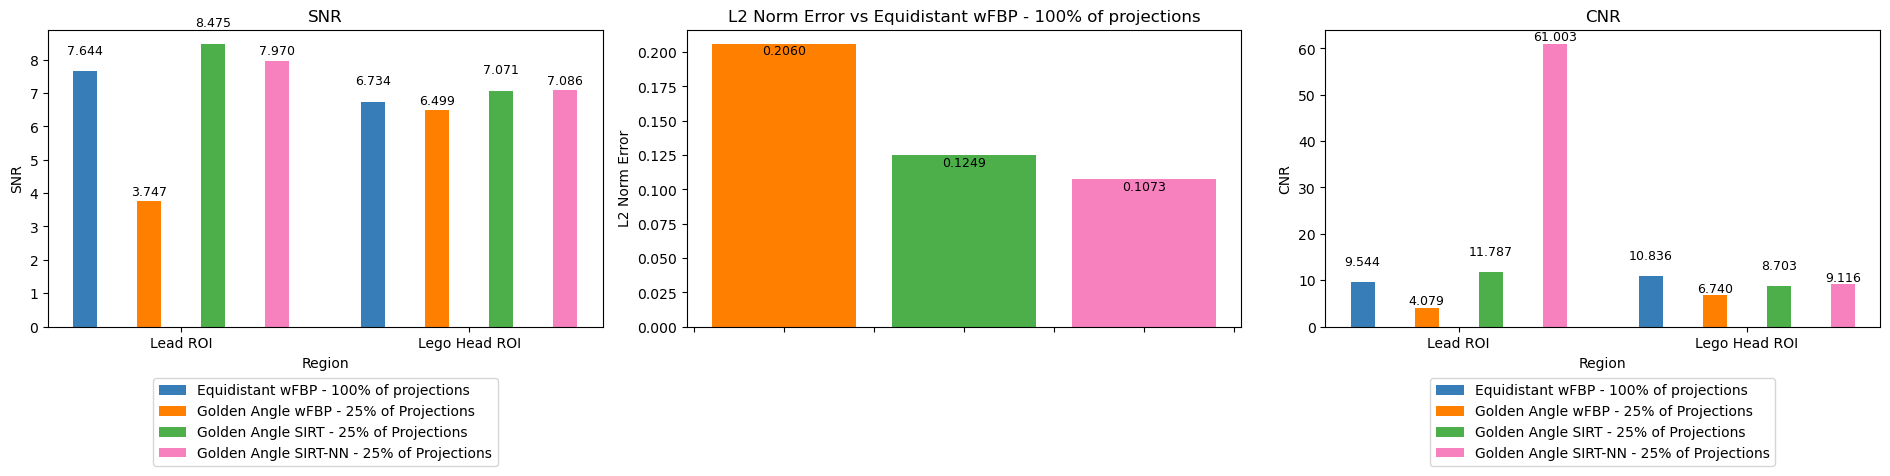

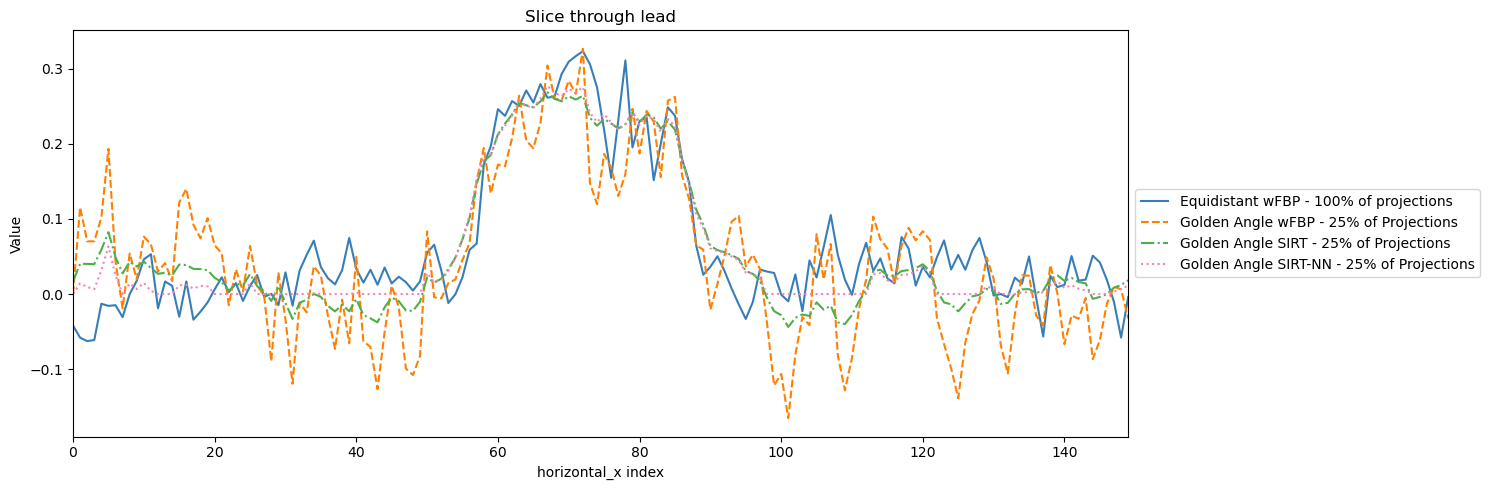

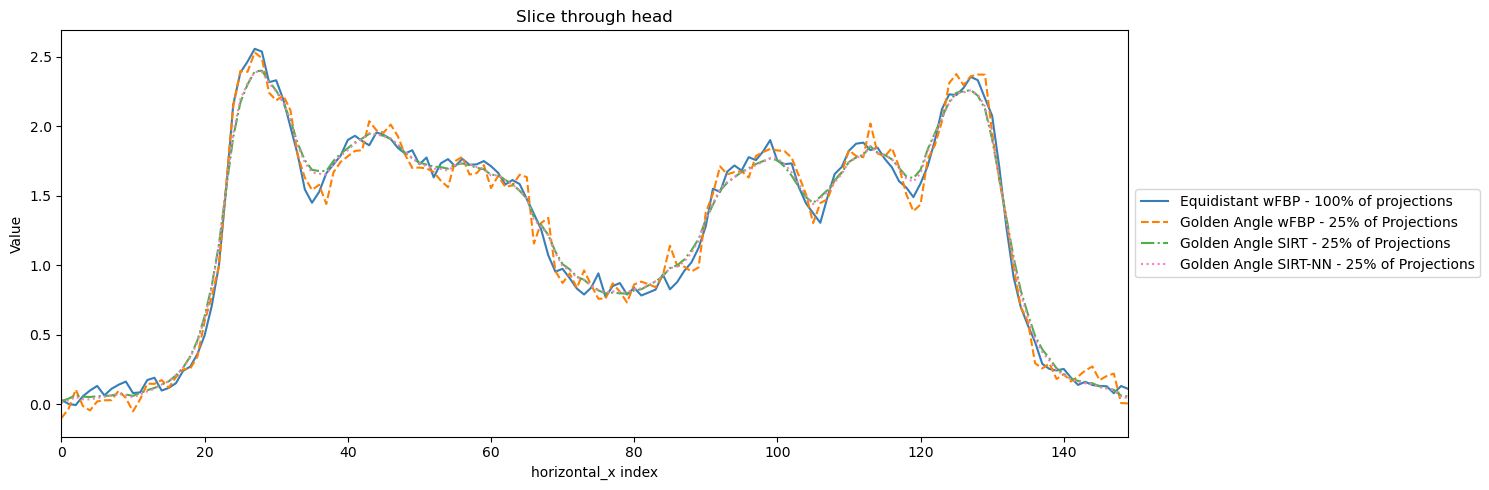

In [17]:
show1d_slicer_lead = Slicer(roi={'horizontal_x':(50,200)})
show1d_slicer_head = Slicer(roi={'horizontal_x':(200,350)})


def show_metrics_and_profiles(gr_scale):
    i = gr_scales.index(gr_scale)

    data = [fbp_results[i], sirt_results[i], sirt_nn_results[i]]
    _titles = titles[i * 4:(i + 1) * 4]

    l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner = calculate_metrics(equi_full_recon, data)
    make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, _titles)

    data_with_ref = [equi_full_recon] + data
    show1D([show1d_slicer_lead(x) for x in data_with_ref], slice_list=[('horizontal_y', 300)],
            dataset_labels=_titles, title="Slice through lead", size=(15, 5))
    show1D([show1d_slicer_head(x) for x in data_with_ref], slice_list=[('horizontal_y', 300)], dataset_labels=_titles,
           title="Slice through head",size=(15, 5))

show_metrics_and_profiles(0.25)


### Line profiles
In both the region cutting through the lead and the region cutting through the lego man's head, we see reduced noise, with smoother line profiles with SIRT and SIRT-NN.

In the line profile showing the lead region we also have the lead between ~60-85 and air outside of that.
In the air region we really see the impact of the non-negativity constraint. The values do not go below zero with SIRT-NN, and it results in less noise, and a flatter line profile.
Through the lead region itself we see similar line profiles with and without non-negativity, but these are certainly smoothed compared to both the reduced golden angle data and even the full equidistant data.

In the line profile through the head, this is going across a slice which goes through approx. the centre of the concentric circles. So we are looking at the boundaries between the head layers, and the dip in the middle of the line profile is the air inside the head. We see smoothing throughout, however some of the dips do not go as low in the SIRT and SIRT-NN results compared to FBP, which means that the algorithms have added extra material into the air regions. However, the dips have not been completely smoothed out - we still see there are dips present.

### Metrics
The regions used in evaluating these metrics are outlined in the Golden_Angle_01_Intro_to_Golden_Ratio_Scanning.ipynb notebook.

We see an improved signal to noise ratio in both the lego and lead regions with SIRT and SIRT-NN compared with both full equidistant and reduced golden angle FBP.

The L2Norm error between the SIRT reconstructions and the full equidistant reconstructions are reduced, with the lowest error with the non-negativity constraint applied.

We see improved contrast to noise between lead and air in both SIRT and SIRT-NN, with a massive value for this metric with SIRT-NN due to the non-negativity constraint providing greater smoothing to the air regions, resulting in a much lower standard deviation in this region.

Although the contrast to noise ratio between the ROI in the lego head and the ROI of air in the centre of the head is improved with SIRT and SIRT-NN compared to the FBP of the 25% golden angle data, it is less than the result with the full equidistant data. This is due to the lower contrast between the central air regions and lego, which we also observed in the line profile

### Summary
With both the SIRT and SIRT-NN algorithms we see less noise across the image. SIRT-NN greatly reduces the noise in the air regions outside the sample.
However, in this smoothing, the SIRT and SIRT-NN algorithms reduce the contrast between the lego and air regions in between the layers of the lego man's head, although these are still improved compared to the weighted FBP reconstruction of the reduced data.




We can also take a look at what happens when we have 50% or 75% of the data:

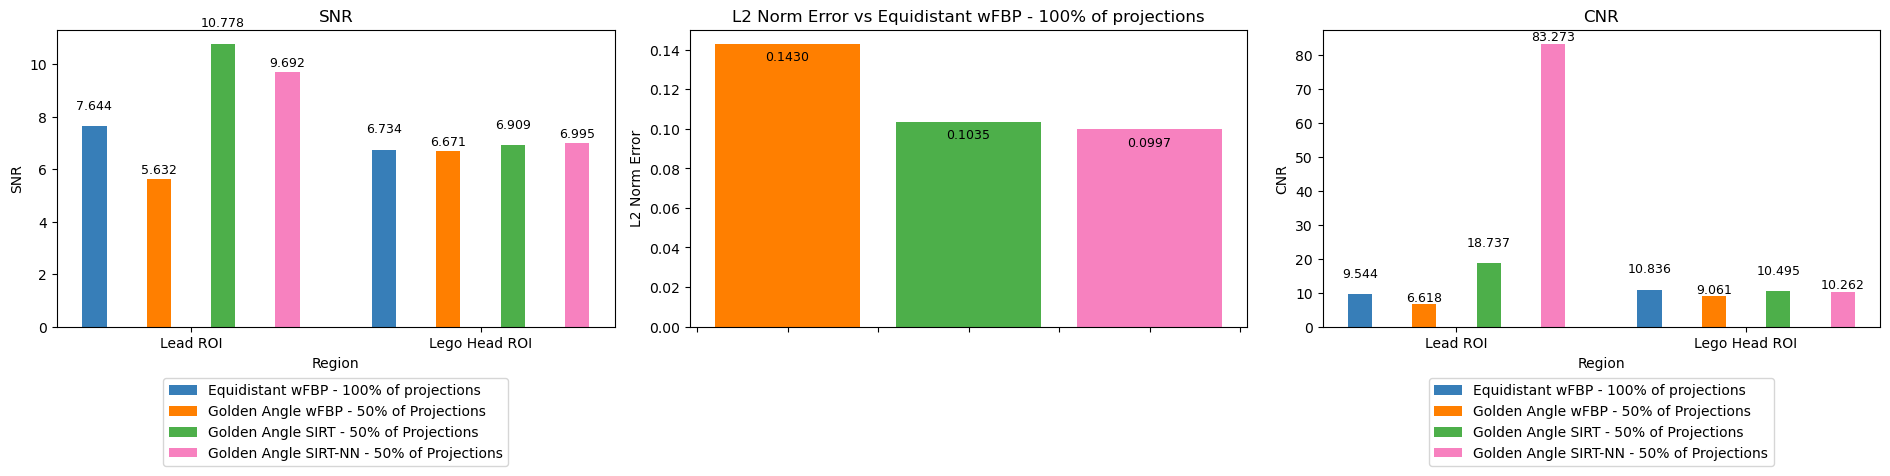

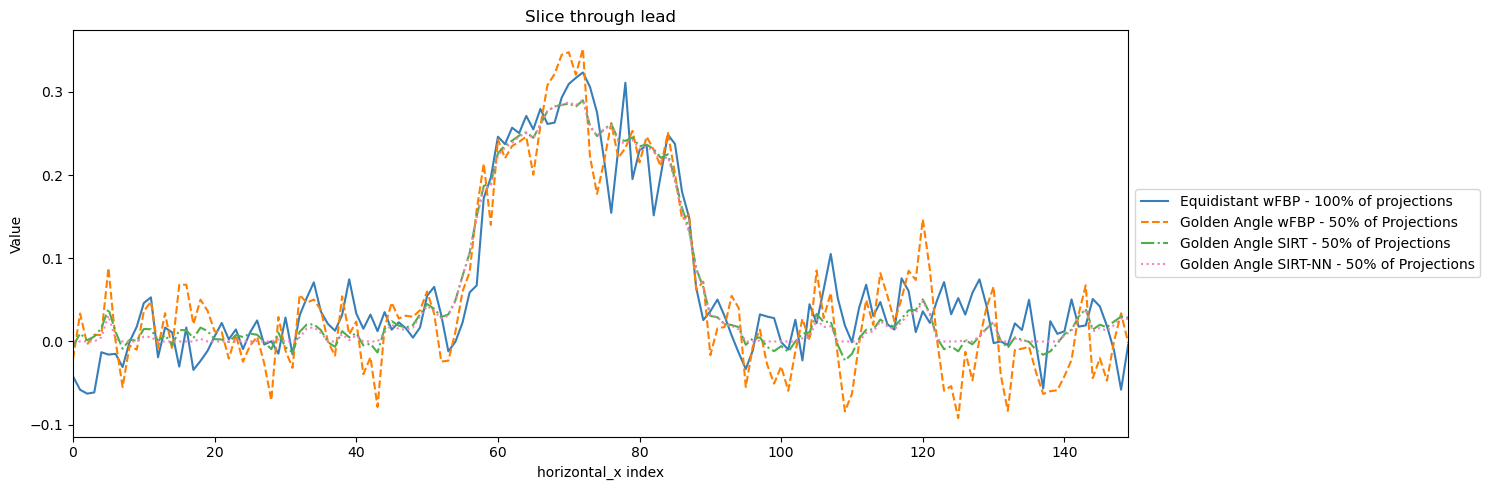

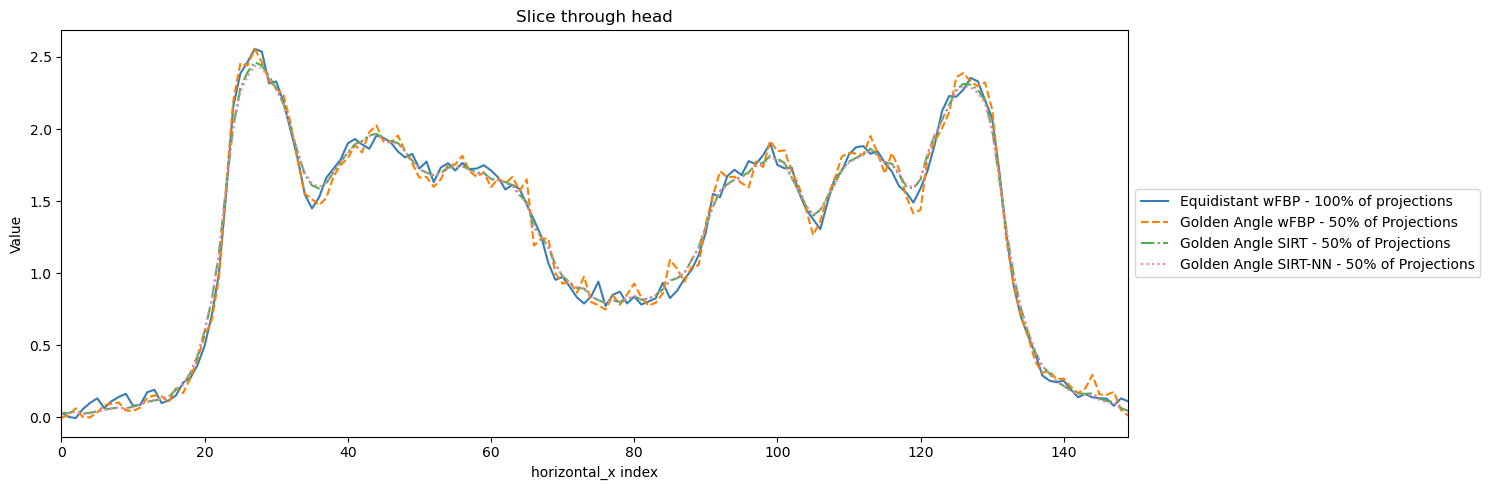

In [18]:
show_metrics_and_profiles(0.5)

We see a similar trend in the metrics when we have 50% of the golden angle data. Most metrics show improved values with the SIRT algorithms with 50% compared to 25% of data.

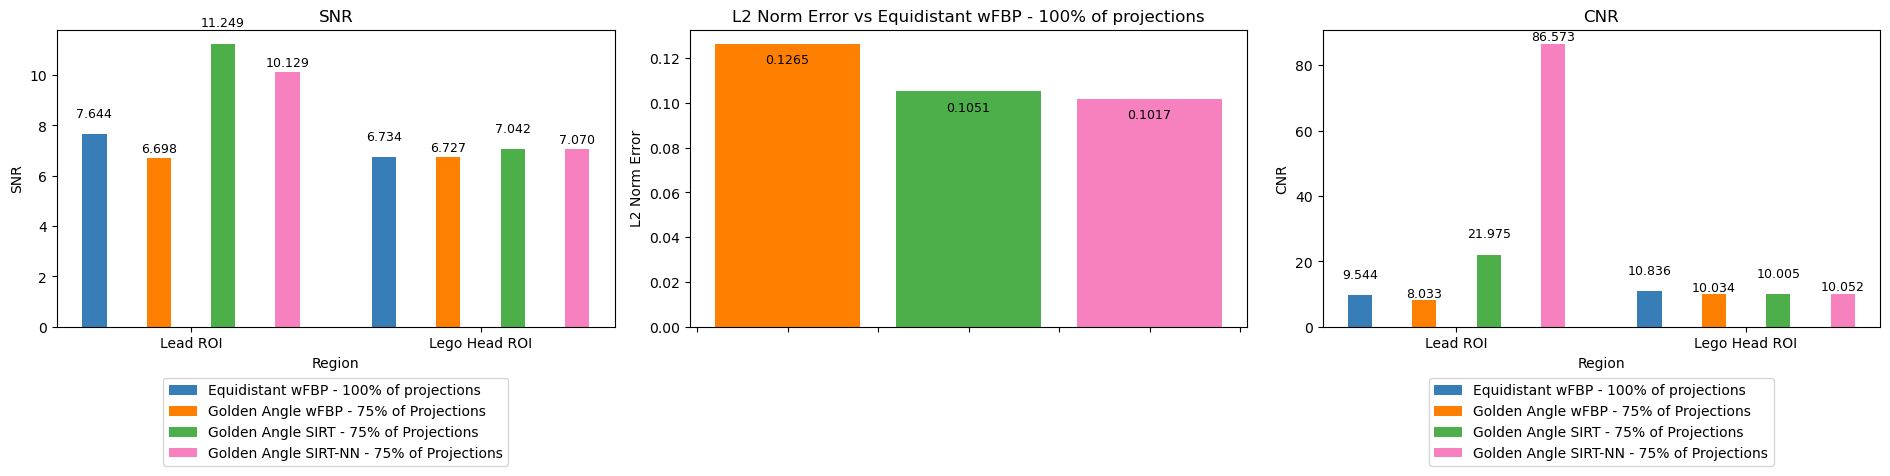

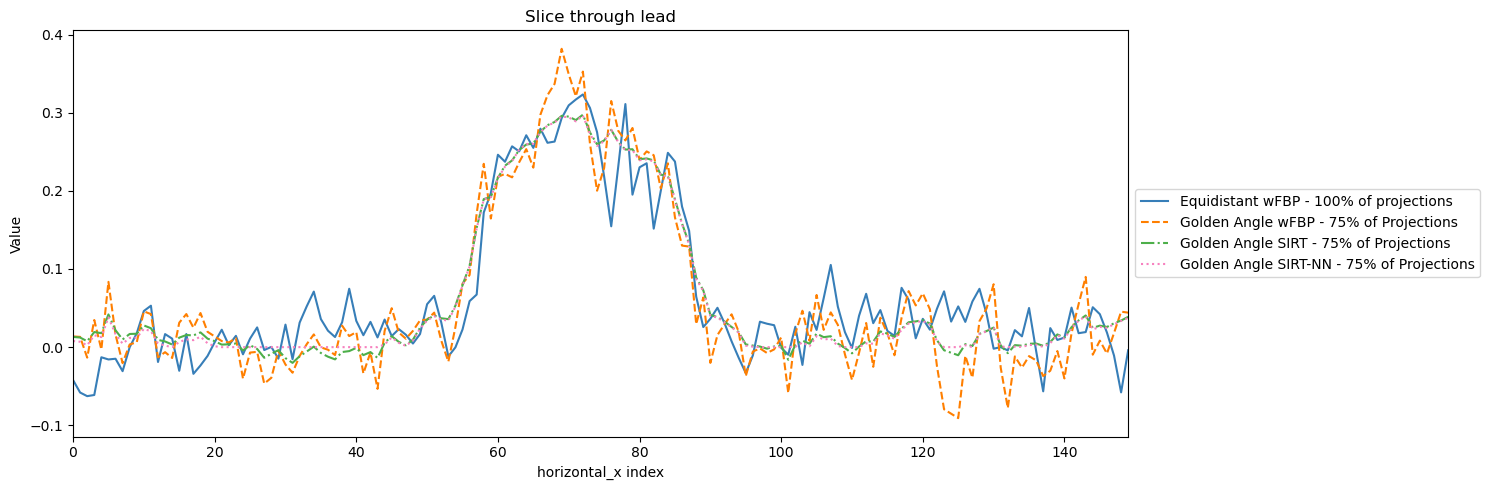

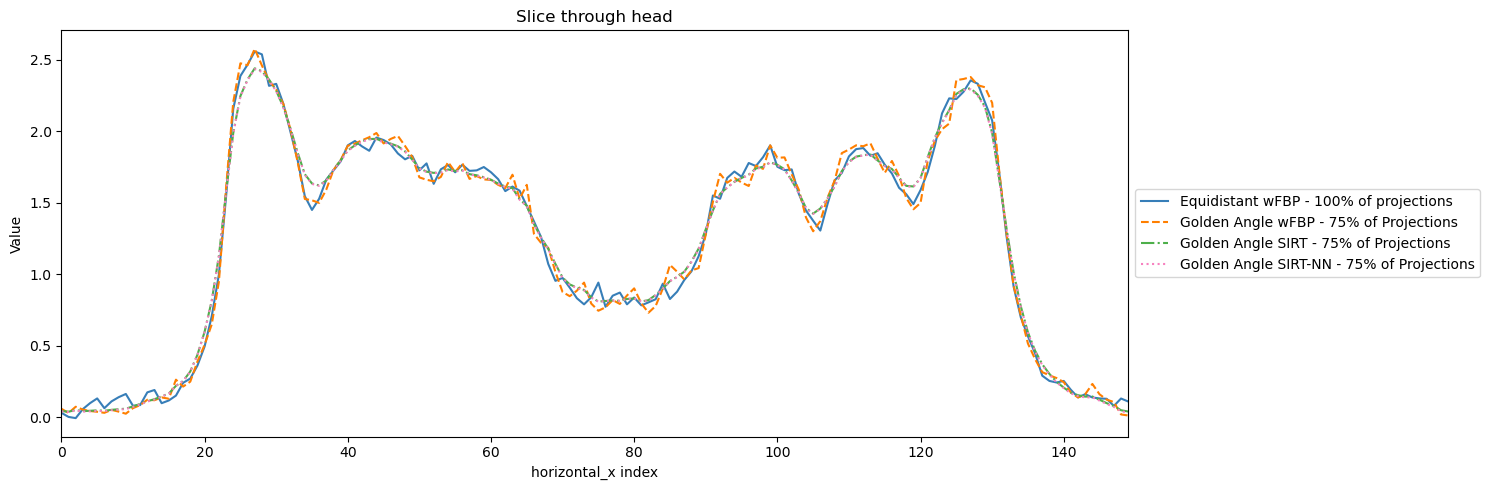

In [19]:
show_metrics_and_profiles(0.75)

The trends and line profiles are similar to above. Some of the metrics perform worse with 75% of projections than with 50% of projections! Examples of what this could be caused by include:
- different angular spacing between acquired projections
- different stopping point in the algorithms

Let's write out our SIRT and SIRT-NN results:

In [ ]:
# make output folder if it doesn't exist
output_folder = "outputs"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
if not os.path.exists(os.path.join(output_folder, "golden_angle_lego")):
    os.makedirs(os.path.join(output_folder, "golden_angle_lego"))

nexus_writer = NEXUSDataWriter(data = sirt_results[0], file_name = os.path.join(output_folder, "golden_angle_lego", "sirt_25_percent.nxs"))
nexus_writer.write()
nexus_writer_2 = NEXUSDataWriter(data = sirt_nn_results[0], file_name = os.path.join(output_folder, "golden_angle_lego", "sirt_nn_25_percent.nxs"))
nexus_writer_2.write()